# Instructions for Calculating Grid-Cell Area Weighted Spatial Averages

This instructional document aims to guide users to quickly understand the core functions of the occ_climate package for processing the area-weighted spatial averages by computing global mean sea surface temperature from a monthly SST climatological observational field.

We are using NOAA's OI SST Monthly Long Term Mean 1991-2020 DataSet from https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.highres.html.

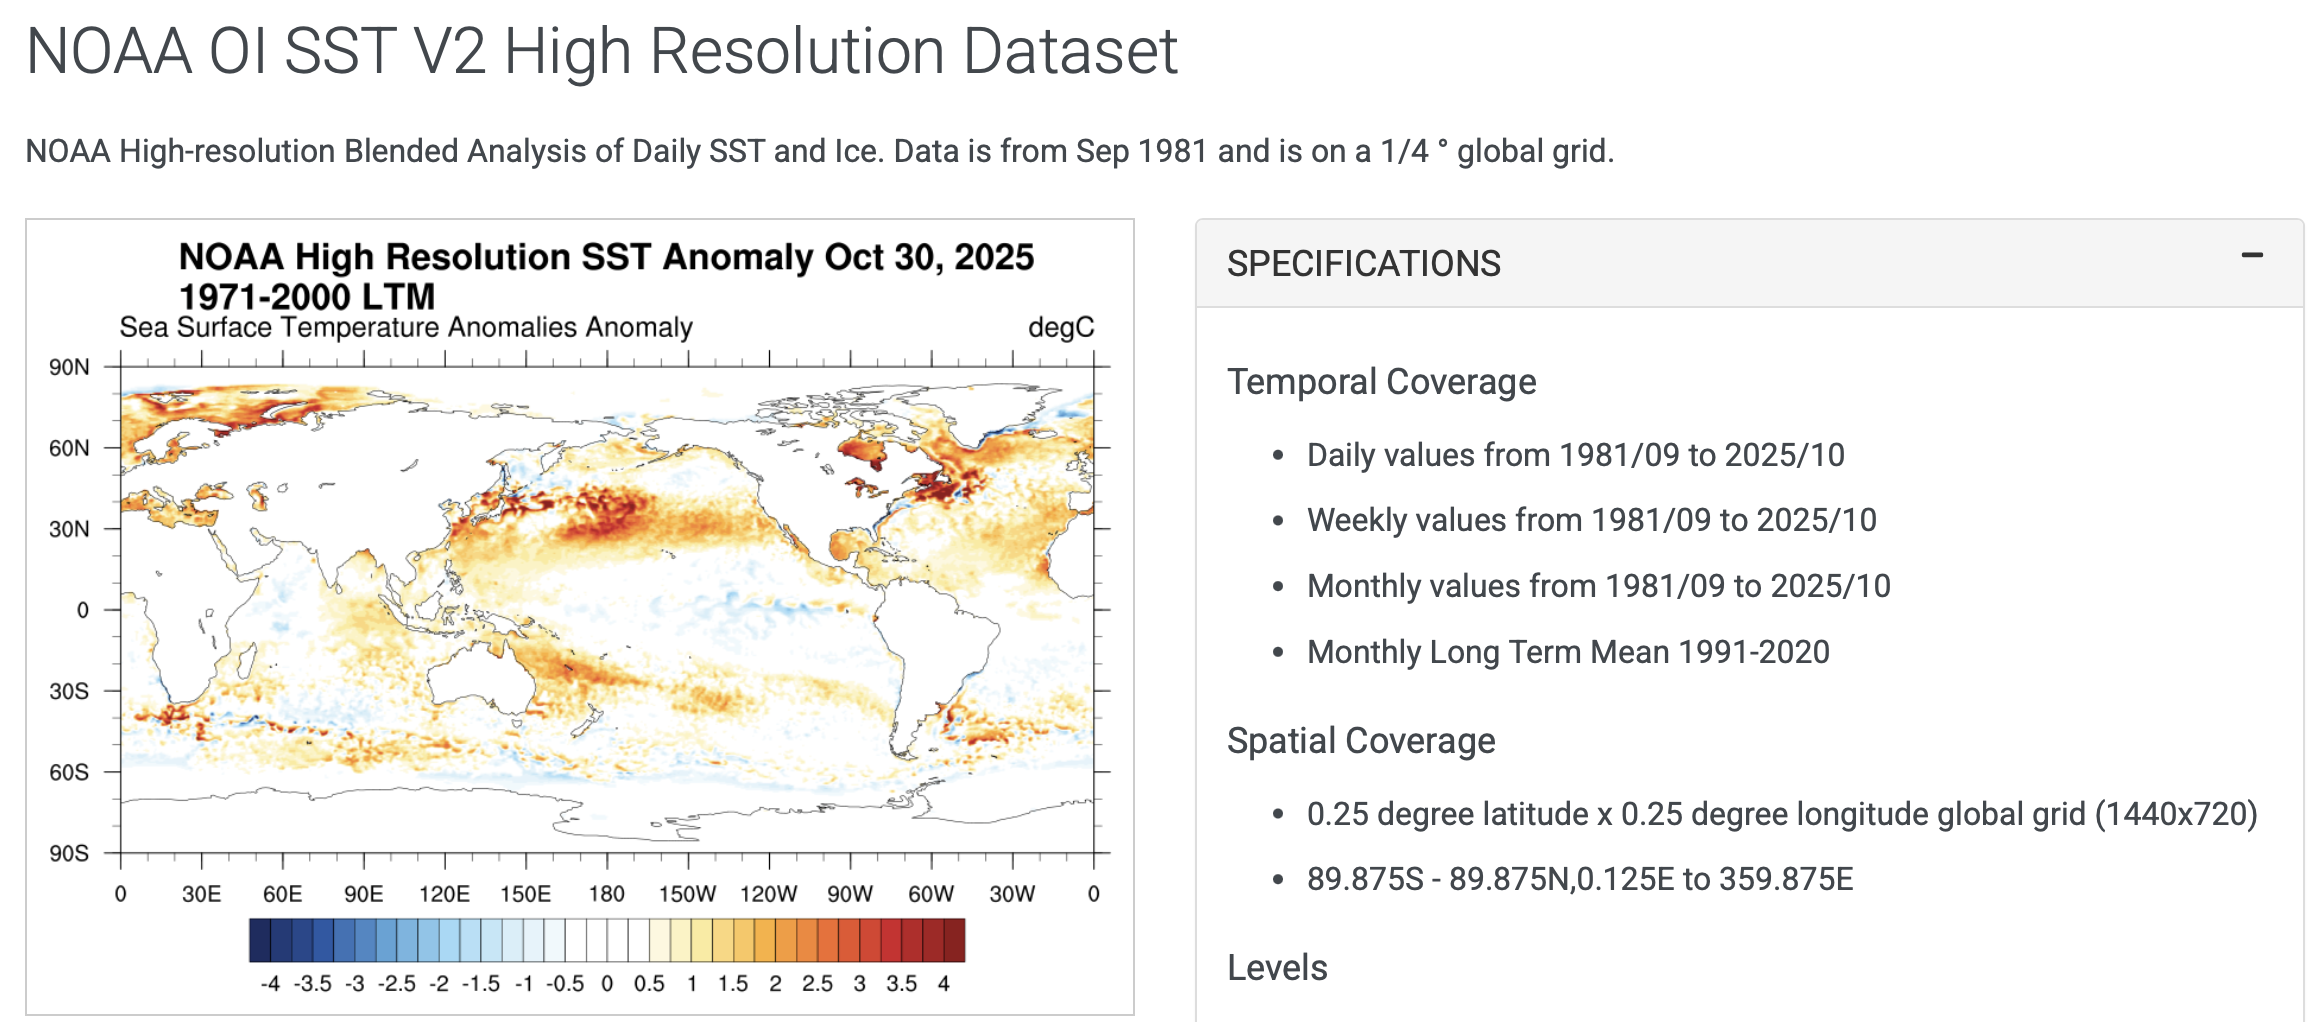

##### __Authors__: Dr. Rebecca L. Beadling, with packaging and tutorial written by Wei Chieh Liu. __Contact__: rebecca.beadling@temple.edu

### 1. Package Installation and Environment Preparation
Before you begin, please ensure that you have installed the occ_climate package and the core scientific computing package required for this tutorial.

In [6]:
import matplotlib.pyplot as plt 
import xarray as xr
import numpy as np 
import occ

Custom configuration for plotting

In [7]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 8,4  
plt.rcParams['figure.dpi'] = 300

### 2. Function: Calculate standard grid cell area

#### 2.1 Meaning and Use of Functions

In Earth science grid data (such as NetCDF archives), using equally spaced latitude and longitude grids leads to a significant problem: __uneven grid area__.

* Equator: Largest longitude spacing, largest grid area.

* Polar regions: Longitude spacing close to zero, smallest grid area.

If area weighting is not applied to the data, direct global or regional spatial averaging will overweight the smaller polar regions, distorting the averaging results.

The `occ.spatial.standard_grid_cell_area` function is specifically designed to calculate the actual area of ​​a standard latitude and longitude grid (considering the Earth's spherical nature), providing the necessary weights for subsequent accurate spatial weighted averaging.

For example, in global temperature data, polar regions with extremely cold temperatures occupy a much smaller area than the warmer areas near the equator, thus contributing less to the global average temperature. By multiplying the temperature by the area of its corresponding grid cell and performing a weighted average, a more physically accurate global average surface temperature can be obtained.

#### 2.2 Function Details

| Parameter Name | Data Type | Description |
|----------------|-----------|-------------|
| lat            | 1D Array  | Latitude coordinate array. |
| lon            | 1D Array  | Longitude coordinate array. |
| rE             | Float (Optional) | Earth's radius (default is 6371.0 × 10³ meters). |

Output: A 2D NumPy array with dimensions (len(lat), len(lon)), where the value is the area of ​​each grid cell (in m²).

#### 2.3 Demonstration Code: Calculate and plot the grid area

In [11]:
# Load OISST climate mean data

SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc', use_cftime=True)

/var/folders/y3/jjb7h7fd4mg_yy8nsvfhwzym0000gn/T/ipykernel_82968/292422648.py:3: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc', use_cftime=True)


In [12]:
# Retrieve the coordinate array of latitude and longitude (1D) from the dataset

lat_sst = SST_OISST.coords['lat'].values #1-D numpy array of model's latitude values
lon_sst = SST_OISST.coords['lon'].values #1-D numpy array of model's longitude values

# make sure to replace the name of the data array if you chose a 
# different name and use the appropriate coordinate names within the ['']
# based on the coordinates of lat / lon in your dataset.

In [13]:
# Call the standard_grid_cell_area function in the occ.spatial module
# The function calculates the area of ​​each grid cell based on the lat/lon spacing and absolute position.

areacell = occ.spatial.standard_grid_cell_area(lat_sst, lon_sst)

In [14]:
# The areacella_xarray function outputs a numpy array. Convert this back into 
# and xarray DataArray for further use. If this is a field you will be using 
# often. You may wish to save this newly created DataArray as a Dataset and save 
# as a netcdf file.

# here we assign dimensions and coordinates that are the same as our original SST array:

areacell_xarray = xr.DataArray(areacell,dims=({'lat':180, 'lon':360}),\
                                                coords=(SST_OISST.coords['lat'],\
                                                        SST_OISST.coords['lon']))

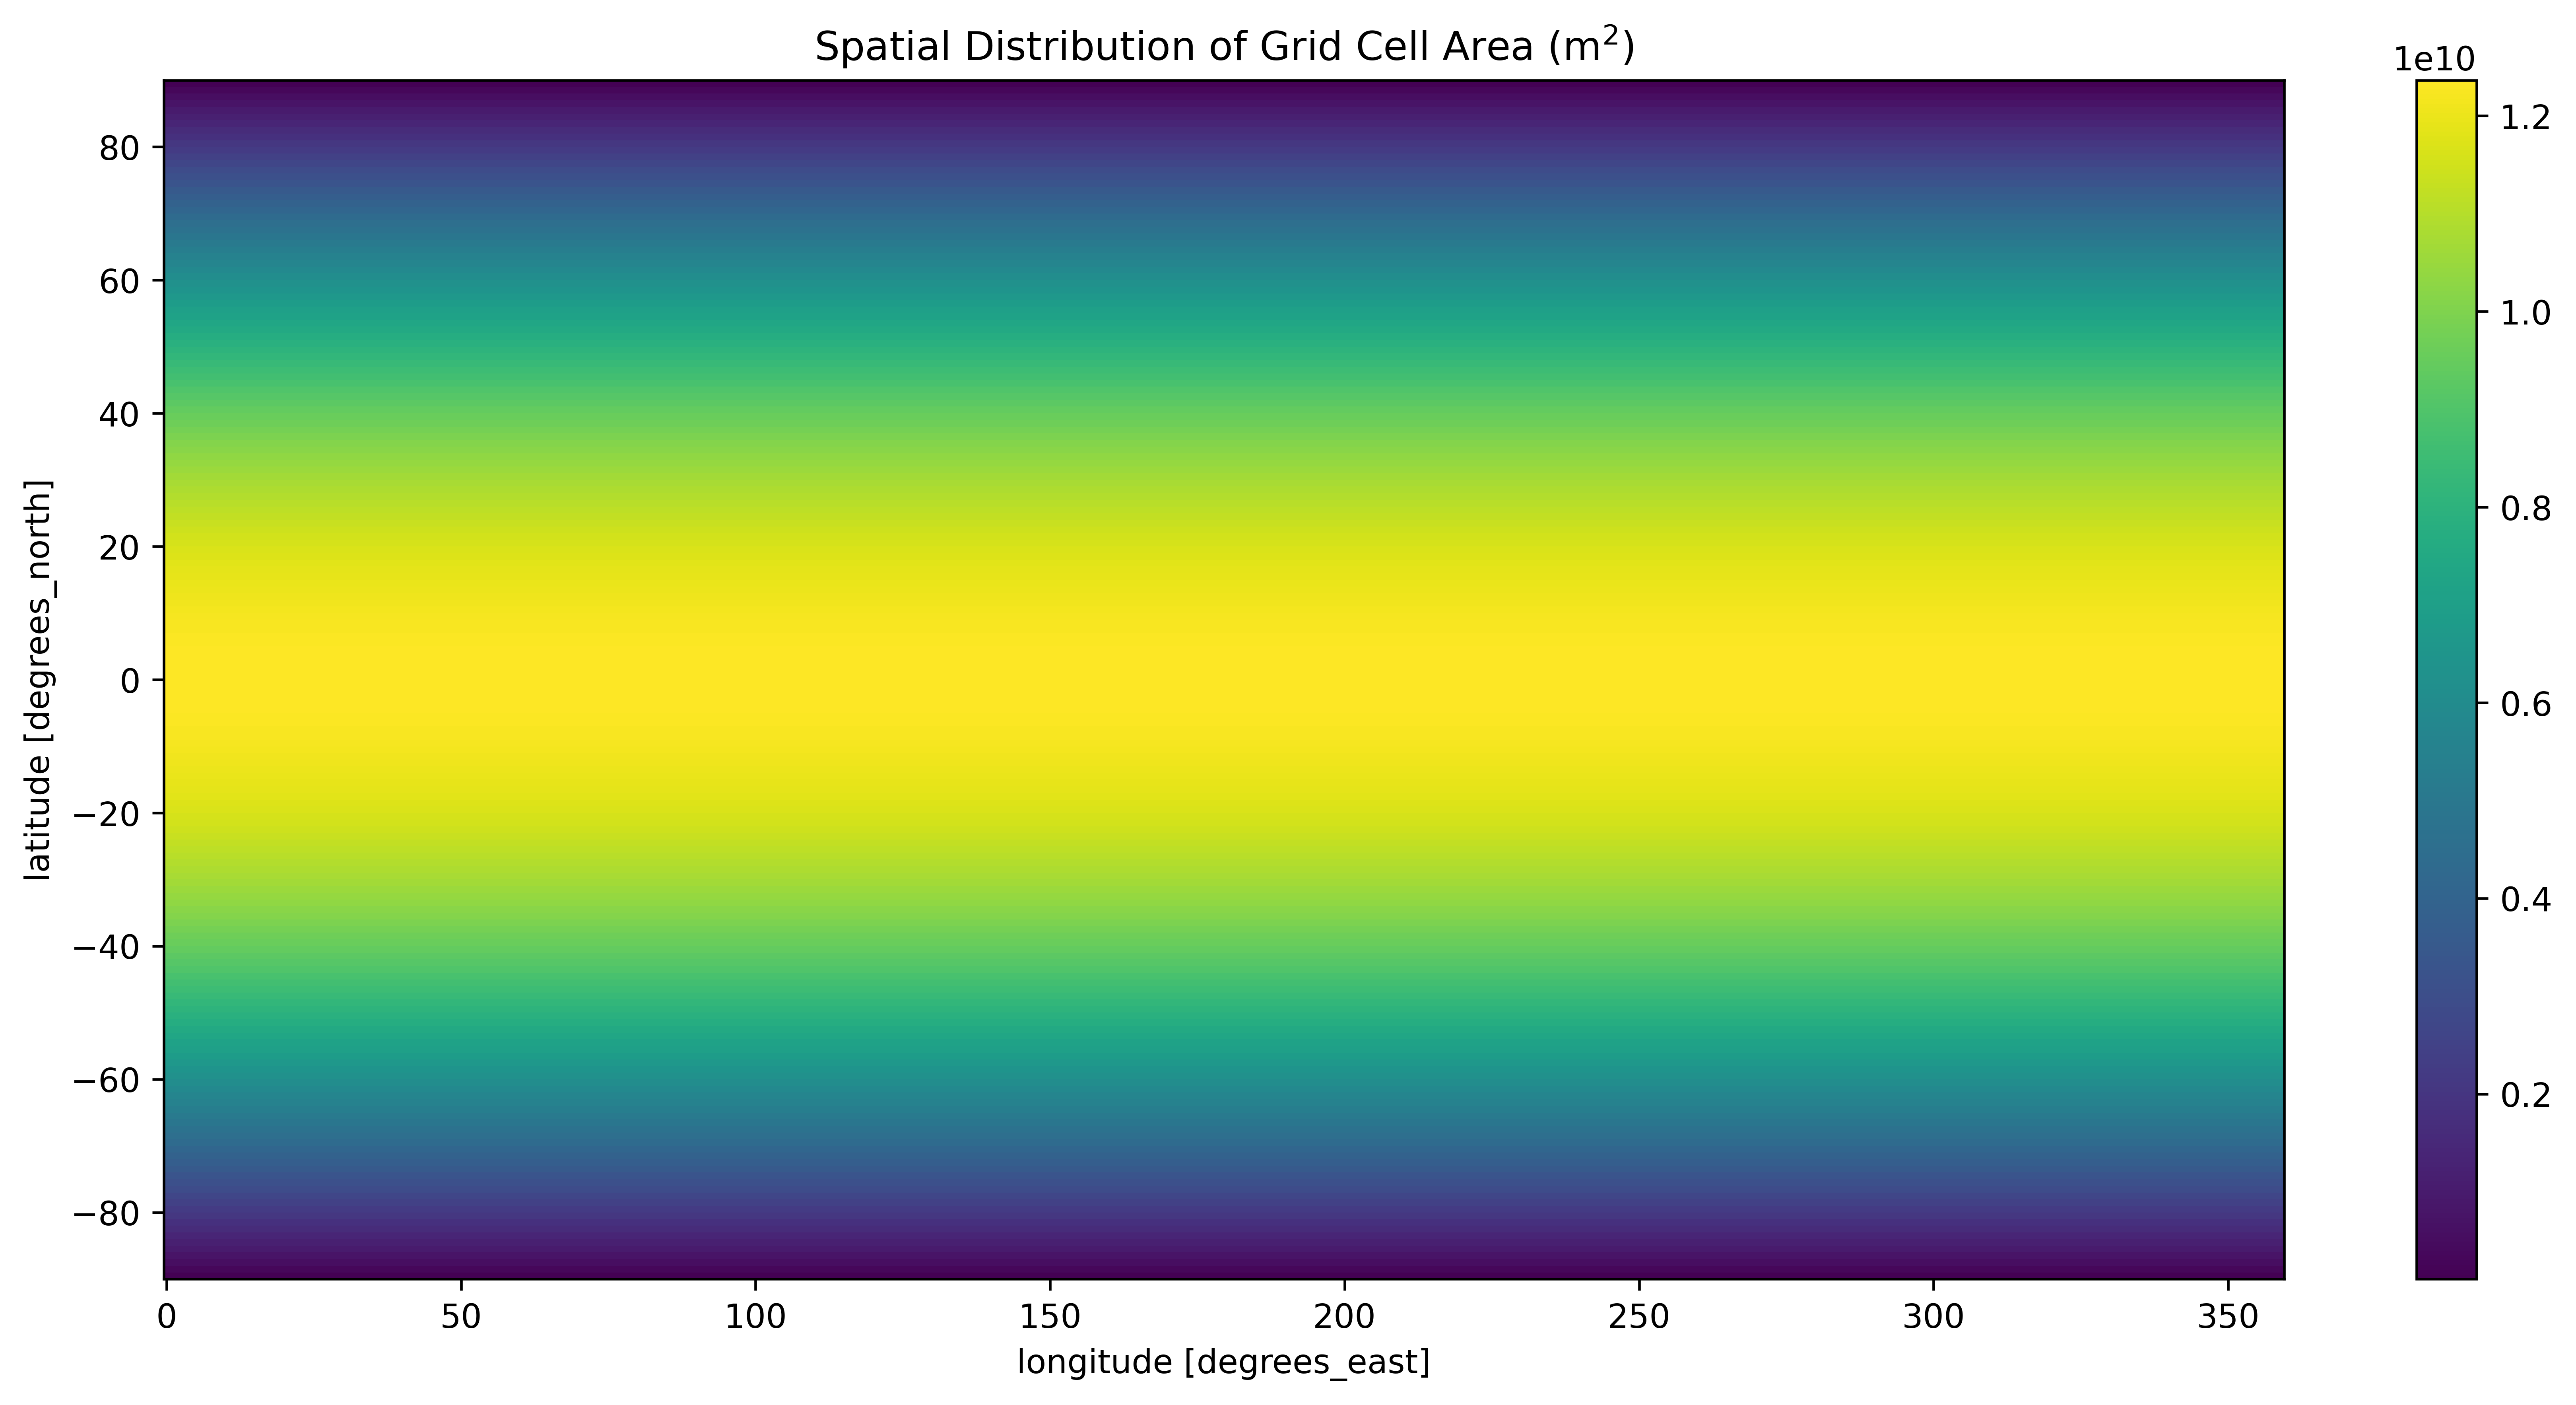

In [16]:
# Plot the grid area distribution

fig, ax = plt.subplots(figsize=(12, 6))

# Use Xarray's plotting functionality, which will automatically map the coordinates to the axes.

areacell_xarray.plot(ax=ax)# Add color bar labels
ax.set_title('Spatial Distribution of Grid Cell Area (m$^{2}$)')

plt.tight_layout()
plt.show()

#### 2.4 Result

After executing the above code, you will see a global map with color bars displaying the area distribution of the grid.

Chart characteristics: The center of the chart (equatorial region, latitude 0°) will show the largest area value and the darkest color. As latitude extends towards the polar regions (90° N/s), the grid area values ​​decrease rapidly, and the color lightens.

This chart visually demonstrates the non-uniformity of the grid area and verifies the correctness of the output of the `standard_grid_cell_area` function, laying the foundation for accurate spatial averaging in your subsequent work.